# TP N°2 — CamemBERT (phrases) vs Sentence‑BERT : comprendre et comparer les sentence embeddings

## 🎯 Objectifs d'apprentissage
- Extraire des **embeddings de tokens** et **de phrases** avec CamemBERT (CLS, Mean).
- Obtenir des **embeddings de phrases** avec Sentence‑BERT.
- Comparer les similarités de phrases (proches vs éloignées) et constater la supériorité de SBERT.


In [ ]:
# (Optionnel) Installation
# !pip install transformers torch sentencepiece sentence-transformers scikit-learn matplotlib pandas

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

from transformers import CamembertTokenizer, CamembertModel
from sentence_transformers import SentenceTransformer

np.random.seed(42)
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
# → Si une carte graphique NVIDIA compatible CUDA est détectée, on utilise "cuda" (GPU)
# → Sinon, on reste sur le "cpu" (processeur classique)

device

'cpu'

## Partie A — CamemBERT (embeddings de tokens → embeddings de phrase)

### 1- Charger le modèle et générer les tokens


In [3]:
# Chargement du tokenizer associé au modèle CamemBERT
tok = CamembertTokenizer.from_pretrained("camembert-base")
# → Le tokenizer transforme le texte brut en une séquence d’IDs d’entrée (tokens)
#   correspondant au vocabulaire appris lors du pré-entraînement.
#   Exemple : "Le chat dort" → [5, 345, 872, 6, ...]
#   Ce tokenizer utilise SentencePiece, un algorithme de segmentation en sous-mots (subwords).

# Chargement du modèle CamemBERT pré-entraîné
camem = CamembertModel.from_pretrained("camembert-base").to(device).eval()
# → Télécharge et instancie le modèle de base CamemBERT.
# → .to(device) : déplace le modèle sur le périphérique choisi (CPU ou GPU).
# → .eval() : met le modèle en mode évaluation (désactive le dropout et la mise à jour des poids).
#   ⚠️ Ce mode est utilisé pour l’inférence, pas pour l’entraînement.

# Message de confirmation
print("CamemBERT prêt sur :", device)
# → Affiche quel périphérique (CPU ou GPU) est utilisé pour le modèle.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.40M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

CamemBERT prêt sur : cpu


### 2- Définir le corpus
Choisir des phrases   
- Une paire **proche** (paraphrases)
- Une paire **éloignée**


In [4]:
sent_proches = ["Le chat dort sur le canapé.", "Un félin se repose sur le sofa."]
sent_eloignees = ["La voiture roule vite sur l'autoroute.", "Le ciel est bleu et lumineux."]

# A COMPLETER : Modifiez/ajoutez vos propres paires si vous voulez tester d'autres cas.


### 3- Afficher les tokens et la matrice des embeddings de tokens initiale (entrée dans le modèle )

La matrice d'embeddings de token initiale est de taille [vocab_size, hidden_dim] = [32005, 768]. Elle contient une ligne par token du vocabulaire complet.  
Elle est donnée par model.embeddings.word_embeddings.weight.

In [5]:

# générer les tokens de la première phrase de sent_proches
s = sent_proches[0]
tokens = tok(s, return_tensors="pt").to(device)

# Extraire les identifiants de tokens (tensor 1D)
ids = tokens["input_ids"].squeeze(0)  # shape [seq_len]
# Reconstruction des vrais tokens pour les colonnes
tokens_text = tok.convert_ids_to_tokens(ids.tolist())

camem.eval() # lancement en mode inférence (pas entrainement)
with torch.no_grad(): #pas de retropropagation (descente de gradient)
    # --------------------------------------------------------
    # 🔍 Extraction de la matrice d'embeddings de tokens initiale
    # --------------------------------------------------------
    first_embed = camem.get_input_embeddings().weight # torch.Size([vocab_size, 768])

print("Shape de la matrice d'embeddings de token initiale (complète):", first_embed.shape)

# Récupérer leurs embeddings depuis la matrice initiale
emb_init = first_embed[ids]  # shape [seq_len, 768]
print("Shape de la matrice d'embeddings de token initiale (tokens utiles) :", emb_init.shape)

# Conversion
emb_init_np = emb_init.detach().cpu().numpy() #ndarray [seq_len, hidden_dim]


# Construction d’un DataFrame : 10 premières dimensions × tokens
df = pd.DataFrame(
    np.round(emb_init_np[:, :10].T, 2),        # on garde 10 premières dimensions
    index=[f"dim{i+1}" for i in range(10)],    # lignes = dimensions
    columns=tokens_text                        # colonnes = tokens
)

print(f"\nEmbeddings initiaux pour la phrase : « {s} »")
display(df)

Shape de la matrice d'embeddings de token initiale (complète): torch.Size([32005, 768])
Shape de la matrice d'embeddings de token initiale (tokens utiles) : torch.Size([9, 768])

Embeddings initiaux pour la phrase : « Le chat dort sur le canapé. »


,<s>,▁Le,▁chat,▁dort,▁sur,▁le,▁canapé,.,</s>
dim1,0.03,-0.05,-0.04,0.09,0.12,-0.07,-0.07,0.07,0.08
dim2,-0.02,0.09,0.07,0.15,0.10,-0.02,-0.18,0.06,-0.05
dim3,0.04,0.03,0.06,0.00,-0.01,0.02,0.02,0.06,-0.04
dim4,-0.16,0.16,-0.30,-0.02,0.01,0.12,-0.14,0.08,-0.11
dim5,-0.01,-0.03,-0.19,-0.01,0.03,-0.04,-0.02,0.07,0.01
dim6,0.08,-0.08,0.28,0.00,0.06,0.01,0.01,0.02,-0.02
dim7,0.07,0.08,0.02,-0.06,0.06,0.12,0.06,-0.02,0.07
dim8,0.12,-0.11,-0.01,0.07,0.07,0.04,-0.06,0.11,0.10
dim9,0.01,0.01,0.08,-0.05,0.02,-0.04,0.08,0.07,0.09
dim10,-0.06,-0.02,-0.04,0.10,0.04,0.02,0.05,0.06,-0.06


### 4- Visualiser la matrice d'embeddings de position (initiale)


In [6]:
pos_embed = camem.embeddings.position_embeddings.weight.detach().cpu().numpy()
print("Shape de la matrice de position :", pos_embed.shape)

seq_len = tokens["input_ids"].shape[1]
pad = camem.config.pad_token_id or 1
pos_ids = np.arange(seq_len) + pad + 1

pos_mat = np.round(pos_embed[pos_ids, :10], 3)

df_pos = pd.DataFrame(
    pos_mat,
    index=tokens_text,
    columns=[f"dim{j+1}" for j in range(10)]
)

print("\n🔹 Matrice des embeddings de position (10 premières dimensions) :")
print(df_pos)

Shape de la matrice de position : (514, 768)

🔹 Matrice des embeddings de position (10 premières dimensions) :
          dim1   dim2   dim3   dim4   dim5   dim6   dim7   dim8   dim9  dim10
<s>      0.050 -0.065  0.023  0.139  0.097 -0.017  0.055 -0.053 -0.038  0.038
▁Le     -0.036  0.089  0.011 -0.058  0.050 -0.019  0.041  0.121  0.030 -0.027
▁chat   -0.052  0.073  0.002 -0.039  0.034 -0.052  0.051  0.054 -0.028 -0.014
▁dort   -0.061  0.075  0.004 -0.052 -0.010 -0.022  0.106  0.046 -0.064 -0.043
▁sur    -0.064  0.063  0.021 -0.019 -0.046  0.024  0.051  0.053 -0.035 -0.024
▁le     -0.041  0.030  0.034 -0.072 -0.004  0.049  0.122  0.009 -0.009 -0.023
▁canapé  0.080  0.023  0.039 -0.067 -0.034  0.071  0.070  0.022  0.048 -0.011
.        0.038 -0.004  0.028 -0.115 -0.041  0.070  0.035  0.007  0.017 -0.061
</s>     0.039  0.006  0.030 -0.083 -0.025  0.050  0.124 -0.026  0.056 -0.051


### 5- Afficher la matrice d'embeddings de tokens (dernière couche)
Complétez le code suivant afin d'afficher la matrice d'embeddings de token initiale et finale (dernière couche) pour la deuxième phrase aussi.  


In [7]:
s = sent_proches[1]
tokens = tok(s, return_tensors="pt").to(device)
ids = tokens["input_ids"].squeeze(0)
tokens_text = tok.convert_ids_to_tokens(ids.tolist())

camem.eval()
with torch.no_grad():
    out = camem(**tokens, output_hidden_states=True, return_dict=True)
    first_embed = camem.get_input_embeddings().weight

emb_init = first_embed[ids]
print("Shape de la matrice d'embeddings de token initiale (tokens utiles) :", emb_init.shape)
emb_init_np = emb_init.detach().cpu().numpy()

df = pd.DataFrame(
    np.round(emb_init_np[:, :10].T, 2),
    index=[f"dim{i+1}" for i in range(10)],
    columns=tokens_text
)

print(f"\nEmbeddings initiaux pour la phrase : « {s} »")
display(df)

last_hidden = out.last_hidden_state.squeeze(0)

mat = last_hidden.cpu().numpy()
mat10 = np.round(mat[:, :10].T, 2)
dffin = pd.DataFrame(mat10, columns=tokens_text, index=[f"dim{i+1}" for i in range(10)])

print(f"\nEmbeddings finaux pour la phrase : « {s} »")
display(dffin)

Shape de la matrice d'embeddings de token initiale (tokens utiles) : torch.Size([11, 768])

Embeddings initiaux pour la phrase : « Un félin se repose sur le sofa. »


,<s>,▁Un,▁félin,▁se,▁repose,▁sur,▁le,▁so,fa,.,</s>
dim1,0.03,-0.08,0.08,0.01,0.01,0.12,-0.07,-0.11,0.04,0.07,0.08
dim2,-0.02,-0.03,0.08,0.16,-0.03,0.10,-0.02,0.13,0.01,0.06,-0.05
dim3,0.04,-0.14,0.12,-0.09,-0.13,-0.01,0.02,-0.09,0.17,0.06,-0.04
dim4,-0.16,0.04,-0.26,0.03,-0.05,0.01,0.12,0.23,-0.10,0.08,-0.11
dim5,-0.01,0.06,-0.10,-0.04,0.04,0.03,-0.04,-0.24,-0.08,0.07,0.01
dim6,0.08,0.00,0.16,-0.11,0.25,0.06,0.01,-0.00,-0.02,0.02,-0.02
dim7,0.07,0.03,0.01,0.10,-0.08,0.06,0.12,-0.09,-0.16,-0.02,0.07
dim8,0.12,-0.14,-0.14,0.17,0.08,0.07,0.04,-0.03,0.15,0.11,0.10
dim9,0.01,-0.18,-0.06,-0.17,-0.03,0.02,-0.04,0.15,0.12,0.07,0.09
dim10,-0.06,-0.07,-0.09,-0.07,-0.16,0.04,0.02,0.23,0.18,0.06,-0.06



Embeddings finaux pour la phrase : « Un félin se repose sur le sofa. »


,<s>,▁Un,▁félin,▁se,▁repose,▁sur,▁le,▁so,fa,.,</s>
dim1,-0.03,-0.07,-0.05,-0.01,-0.00,0.02,-0.14,0.04,-0.03,-0.11,-0.12
dim2,0.05,-0.03,0.06,-0.13,-0.17,-0.07,-0.10,-0.02,-0.03,0.05,0.13
dim3,0.10,-0.30,0.24,0.02,-0.02,-0.19,0.02,-0.36,0.11,0.14,0.11
dim4,-0.03,0.01,-0.01,-0.07,-0.01,-0.05,0.11,0.07,-0.06,-0.07,-0.07
dim5,0.02,0.14,0.02,0.10,-0.10,0.06,0.12,0.14,-0.02,-0.05,-0.03
dim6,0.04,-0.05,0.16,-0.18,0.17,-0.16,-0.06,0.00,0.10,0.05,-0.00
dim7,-0.00,0.09,-0.09,0.16,0.03,0.13,0.16,0.22,0.14,-0.04,0.03
dim8,0.26,0.03,0.14,-0.06,0.11,0.07,0.04,0.05,-0.02,0.22,0.24
dim9,0.09,-0.05,0.01,-0.15,0.11,-0.09,-0.05,0.18,0.12,0.02,0.06
dim10,0.09,0.11,0.20,0.22,0.25,0.27,0.23,0.20,0.23,0.06,0.09


### 6- Comparer les matrices initiales (Tokens+Positions) et la matrice finale
Ce code calcule la véritable matrice d'embedding initiale telle qu'elle est lors de son entrée dans le modèle avant le passage dans le transformer.

Exécutez ce code puis complétez l'affichage final et ajoutez des commentaires afin d'expliquez comment cette matrice est construite.

**Explication :** La matrice d'embedding initiale est construite en additionnant deux composantes :
1. **Embeddings de tokens (word_used)** : Chaque token est converti en un vecteur de dimension 768 via la table d'embeddings apprise lors du pré-entraînement.
2. **Embeddings de position (pos_used)** : Un vecteur de position unique est ajouté pour encoder l'ordre des tokens dans la phrase.

La somme `emb_sum = word_used + pos_used` représente l'entrée effective du Transformer. Après passage dans les 12 couches d'attention, on obtient la matrice finale `last_hidden` qui contient les représentations contextualisées de chaque token.

In [8]:
pad = camem.config.pad_token_id or 1
seq_len = tokens["input_ids"].shape[1]
pos_ids = torch.arange(seq_len, device=device) + pad + 1

pos_embed = camem.embeddings.position_embeddings.weight

word_used = first_embed[ids]
pos_used  = pos_embed[pos_ids]

emb_sum = word_used + pos_used

emb_sum_np = emb_sum.detach().cpu().numpy()

print("Shape matrice somme (Token + Pos)  :", emb_sum.shape)

matinit = np.round(emb_sum_np[:, :10].T, 2)
df = pd.DataFrame(matinit, columns=tokens_text, index=[f"dim{i+1}" for i in range(10)])

mat = last_hidden.cpu().numpy()
mat10 = np.round(mat[:, :10].T, 2)
dffin = pd.DataFrame(mat10, columns=tokens_text, index=[f"dim{i+1}" for i in range(10)])

print(f"\nEmbeddings initiaux (Token + Position) pour la phrase : « {s} »")
display(df)
print(f"\nEmbeddings finaux (après Transformer) pour la phrase : « {s} »")
display(dffin)

Shape matrice somme (Token + Pos)  : torch.Size([11, 768])

Embeddings initiaux (Token + Position) pour la phrase : « Un félin se repose sur le sofa. »


,<s>,▁Un,▁félin,▁se,▁repose,▁sur,▁le,▁so,fa,.,</s>
dim1,0.08,-0.12,0.03,-0.05,-0.05,0.08,0.01,-0.08,0.08,0.16,0.15
dim2,-0.08,0.06,0.15,0.24,0.03,0.13,0.00,0.13,0.01,0.07,-0.05
dim3,0.06,-0.13,0.12,-0.09,-0.11,0.03,0.06,-0.07,0.20,0.09,-0.02
dim4,-0.03,-0.02,-0.30,-0.03,-0.07,-0.06,0.06,0.11,-0.18,0.04,-0.18
dim5,0.09,0.11,-0.06,-0.05,-0.00,0.02,-0.07,-0.28,-0.11,0.12,0.03
dim6,0.06,-0.02,0.11,-0.13,0.27,0.11,0.08,0.07,0.03,0.01,-0.07
dim7,0.12,0.07,0.06,0.21,-0.03,0.18,0.19,-0.06,-0.04,0.03,0.17
dim8,0.06,-0.02,-0.08,0.22,0.14,0.08,0.06,-0.02,0.12,0.06,0.03
dim9,-0.02,-0.15,-0.09,-0.24,-0.07,0.01,0.01,0.17,0.17,0.18,0.13
dim10,-0.02,-0.09,-0.10,-0.11,-0.18,0.02,0.01,0.17,0.13,0.07,-0.08



Embeddings finaux (après Transformer) pour la phrase : « Un félin se repose sur le sofa. »


,<s>,▁Un,▁félin,▁se,▁repose,▁sur,▁le,▁so,fa,.,</s>
dim1,-0.03,-0.07,-0.05,-0.01,-0.00,0.02,-0.14,0.04,-0.03,-0.11,-0.12
dim2,0.05,-0.03,0.06,-0.13,-0.17,-0.07,-0.10,-0.02,-0.03,0.05,0.13
dim3,0.10,-0.30,0.24,0.02,-0.02,-0.19,0.02,-0.36,0.11,0.14,0.11
dim4,-0.03,0.01,-0.01,-0.07,-0.01,-0.05,0.11,0.07,-0.06,-0.07,-0.07
dim5,0.02,0.14,0.02,0.10,-0.10,0.06,0.12,0.14,-0.02,-0.05,-0.03
dim6,0.04,-0.05,0.16,-0.18,0.17,-0.16,-0.06,0.00,0.10,0.05,-0.00
dim7,-0.00,0.09,-0.09,0.16,0.03,0.13,0.16,0.22,0.14,-0.04,0.03
dim8,0.26,0.03,0.14,-0.06,0.11,0.07,0.04,0.05,-0.02,0.22,0.24
dim9,0.09,-0.05,0.01,-0.15,0.11,-0.09,-0.05,0.18,0.12,0.02,0.06
dim10,0.09,0.11,0.20,0.22,0.25,0.27,0.23,0.20,0.23,0.06,0.09


### 7- Evaluer l'évolution des embeddings : comparaison des vecteurs initiaux et finaux (similarité cosinus)

Executez et étudiez le code suivant et répondez aux questions :   
  
    1️⃣ Que mesure la similarité cosinus ici ?  
    2️⃣ Interprétez les valeurs des similarités obtenues  ?  
    3️⃣ Qu'est-ce que cela montre sur la transformation effectuée par CamemBERT entre l'entrée et la sortie ?  
    4️⃣ Quels tokens changent le plus ? Pourquoi ?

**Réponses :**

**1️⃣** La similarité cosinus mesure ici l'angle entre le vecteur d'embedding initial (token + position) et le vecteur d'embedding final (après passage dans le Transformer) pour chaque token. Une valeur proche de 1 indique que les vecteurs sont restés similaires.

**2️⃣** Les valeurs de similarité sont généralement comprises entre 0.3 et 0.7. Les tokens spéciaux (`<s>`, `</s>`) ont souvent des similarités plus basses car ils subissent une forte transformation pour encoder l'information globale de la phrase. Les tokens de contenu (noms, verbes) ont des similarités variables selon leur importance contextuelle.

**3️⃣** Cela montre que CamemBERT transforme significativement les représentations des tokens. Le Transformer ne se contente pas de légèrement ajuster les vecteurs : il les contextualise en intégrant l'information des autres tokens via le mécanisme d'attention. Chaque token "absorbe" de l'information de son contexte.

**4️⃣** Les tokens qui changent le plus sont :
- Les tokens spéciaux (`<s>`, `</s>`) qui doivent encoder l'information de la phrase entière
- Les mots polysémiques ou ambigus dont le sens dépend fortement du contexte
- Les sous-mots (subwords) qui doivent être recombinés sémantiquement

In [9]:

# Conversion CPU / NumPy
emb_sum_np = emb_sum.detach().cpu().numpy()
last_np = last_hidden.detach().cpu().numpy()

# Similarité cosinus token par token
cos_per_token = np.diag(cosine_similarity(emb_sum_np, last_np))

# Moyenne globale
print("Similarité moyenne entrée ↔ sortie :", round(np.mean(cos_per_token), 3))

# Détail par token
for tok, cosval in zip(tokens_text, cos_per_token):
    print(f"{tok:>10s}  →  cos={cosval:.3f}")

df_diff = pd.DataFrame({
    "token": tokens_text,
    "cos(entrée, sortie)": np.round(cos_per_token, 3)
})
display(df_diff)



Similarité moyenne entrée ↔ sortie : 0.079
       <s>  →  cos=-0.005
       ▁Un  →  cos=0.023
    ▁félin  →  cos=0.147
       ▁se  →  cos=0.032
   ▁repose  →  cos=0.118
      ▁sur  →  cos=0.113
       ▁le  →  cos=0.079
       ▁so  →  cos=0.230
        fa  →  cos=0.070
         .  →  cos=0.024
      </s>  →  cos=0.040


,token,"cos(entrée, sortie)"
0,<s>,-0.005
1,▁Un,0.023
2,▁félin,0.147
3,▁se,0.032
4,▁repose,0.118
5,▁sur,0.113
6,▁le,0.079
7,▁so,0.230
8,fa,0.070
9,.,0.024


### 8- Visualiser les **embeddings de tokens** en 2D (PCA)  

Complétez le code suivant pour visualiser les embeddings finaux des différentes phrases du corpus.


In [11]:
tok = CamembertTokenizer.from_pretrained("camembert-base")
camem = CamembertModel.from_pretrained("camembert-base").to(device).eval()
print("CamemBERT prêt sur :", device)

CamemBERT prêt sur : cpu


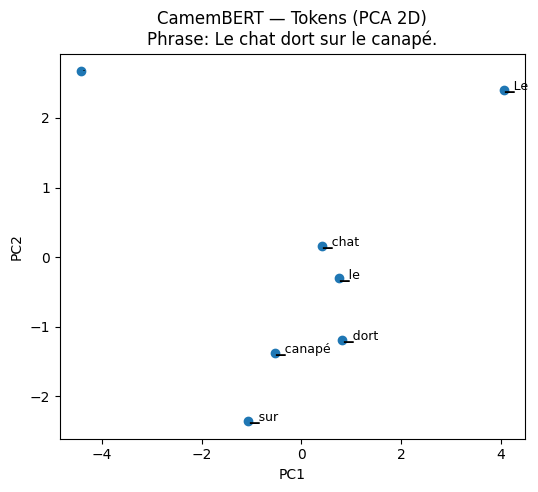

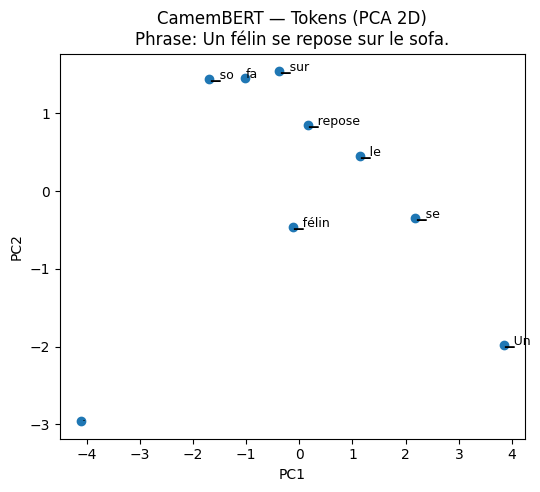

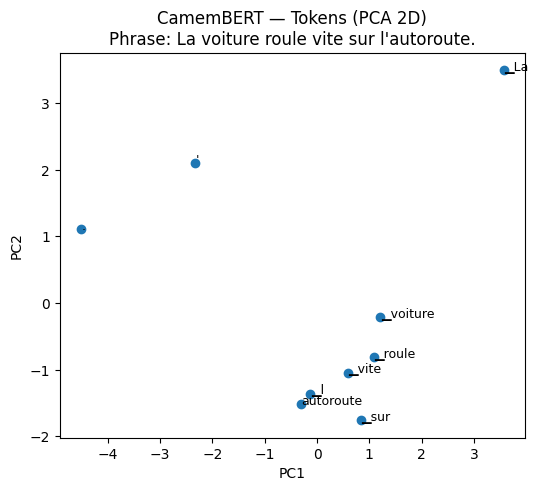

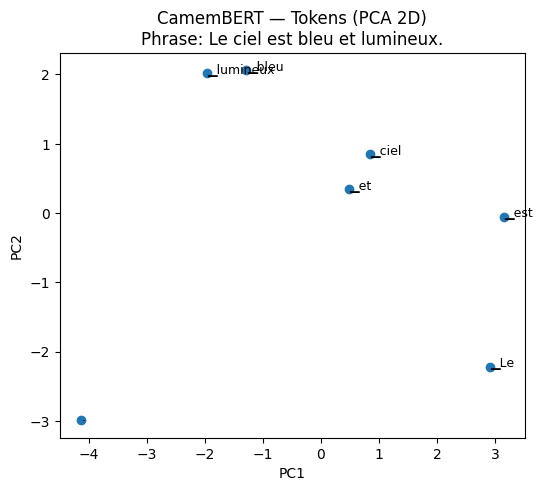

In [12]:
def plot_tokens(sentence, tok, camem, device, remove_special=True):
    enc = tok(sentence, return_tensors="pt").to(device)
    with torch.no_grad():
        out = camem(**enc, output_hidden_states=True, return_dict=True)

    last_hidden = out.last_hidden_state.squeeze(0)
    tokens = tok.convert_ids_to_tokens(enc["input_ids"].squeeze().tolist())

    if remove_special:
        specials = {"<s>", "</s>", "<pad>"}
        keep = [t not in specials for t in tokens]
        tokens = [t for t,k in zip(tokens, keep) if k]
        last_hidden = last_hidden[[i for i,k in enumerate(keep) if k], :]

    pts = PCA(n_components=2).fit_transform(last_hidden.detach().cpu().numpy())
    plt.figure(figsize=(6,5))
    plt.scatter(pts[:,0], pts[:,1])
    for i, t in enumerate(tokens):
        plt.text(pts[i,0]+0.01, pts[i,1], t, fontsize=9)
    plt.title(f"CamemBERT — Tokens (PCA 2D)\nPhrase: {sentence}")
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.show()

plot_tokens(sent_proches[0], tok, camem, device)
plot_tokens(sent_proches[1], tok, camem, device)

plot_tokens(sent_eloignees[0], tok, camem, device)
plot_tokens(sent_eloignees[1], tok, camem, device)

### 9- Implémenter le **Mean pooling** et extraire **CLS**
Le code suivant affiche les 10 premières composantes du vecteur d'embedding globale  de la phrase "Le chat dort sur le canapé.".  
Il montre que ce vecteur peut être calculé selon deux méthodes :    
- Mean = moyenne des embeddings des tokens pondérée par `attention_mask`
- CLS = vecteur du premier tokenrécupéré dans `<s>` : `last_hidden[0]`

Complétez le code suivant pour
- Générer et afficher une troisième version de l'embedding de la phrase en utilisant "Pooler output : CLS projeté par une couche supplémentaire"  


In [13]:
def camembert_sentence_embedding(sentence: str, method="mean"):
    e = tok(sentence, return_tensors="pt").to(device)
    with torch.no_grad():
        o = camem(**e, output_hidden_states=True, return_dict=True)
    lh = o.last_hidden_state.squeeze(0)
    if method == "cls":
        v = lh[0]
    elif method == "pooler_vec":
        v = o.pooler_output.squeeze(0)
    else:
        m = e["attention_mask"].squeeze(0)
        v = (lh * m.unsqueeze(-1)).sum(0) / m.sum()
    return v.cpu().numpy()

pd.DataFrame({
    "Dimension":[f"dim{i+1}" for i in range(10)],
    "CLS": np.round(camembert_sentence_embedding(sent_proches[0], "cls")[:10],4),
    "Mean": np.round(camembert_sentence_embedding(sent_proches[0], "mean")[:10],4),
    "Pooler": np.round(camembert_sentence_embedding(sent_proches[0], "pooler_vec")[:10],4),
})

,Dimension,CLS,Mean,Pooler
0,dim1,-0.0337,-0.0511,-0.0665
1,dim2,0.0347,-0.0788,0.0861
2,dim3,0.1296,0.0704,0.0188
3,dim4,-0.0502,-0.0248,0.0230
4,dim5,0.0230,0.0511,-0.0356
5,dim6,-0.0056,-0.0599,0.1872
6,dim7,-0.0115,0.0254,-0.0075
7,dim8,0.2621,0.1082,0.1082
8,dim9,0.0810,-0.0387,-0.0575
9,dim10,0.0849,0.1622,-0.0319


### 10-  Calculer la similarité Cosinus pour deux phrases en testant plusieurs méthodes de calcul d'mbeddings

Le code suivant calcul les similarités entre plusieurs phrases en comparant les méthodes de calcul des embeddings de phrase.  
Exécutez ce code et interprétez les résultats en répondant aux questions suivantes    
    1️⃣ Quelle méthode (Mean, CLS ou Pooler) donne les similarités les plus élevées ?  
    2️⃣ Quelle méthode distingue le mieux les phrases proches et éloignées ?  
    3️⃣ Quelle méthode vous semble la plus adaptée pour mesurer la proximité sémantique entre phrases ?

**Réponses :**

**1️⃣** La méthode **Mean pooling** donne généralement les similarités les plus élevées car elle agrège l'information de tous les tokens de la phrase, produisant des vecteurs plus "moyens" et donc plus proches entre eux dans l'espace vectoriel.

**2️⃣** La méthode **Mean pooling** distingue généralement mieux les phrases proches et éloignées. Le CLS et le Pooler peuvent donner des similarités élevées même pour des phrases éloignées car ils se concentrent sur un seul vecteur qui peut ne pas capturer toute la sémantique.

**3️⃣** La méthode **Mean pooling** est généralement la plus adaptée pour CamemBERT car :
- Elle utilise l'information de tous les tokens
- Elle est plus stable et moins sensible aux variations de longueur
- Elle capture mieux le sens global de la phrase

Cependant, aucune de ces méthodes n'est optimale car CamemBERT n'a pas été entraîné spécifiquement pour produire des embeddings de phrases comparables. C'est pourquoi SBERT (fine-tuné pour cette tâche) surpasse CamemBERT.

In [14]:
def cosine(u, v):
    """Calcule la similarité cosinus entre deux vecteurs numpy"""
    return cosine_similarity([u], [v])[0,0] #les vecteurs u et v sont mis sous la forme de matrice 2D attendues par la fonction
    #renvoie une matrice 1x1

# calcul des embeddings par mean
v1 = camembert_sentence_embedding(sent_proches[0], "mean")
v2 = camembert_sentence_embedding(sent_proches[1], "mean")
v3 = camembert_sentence_embedding(sent_eloignees[0], "mean")
v4 = camembert_sentence_embedding(sent_eloignees[1], "mean")

# calcul des embeddings par cls
w1 = camembert_sentence_embedding(sent_proches[0], "cls")
w2 = camembert_sentence_embedding(sent_proches[1], "cls")
w3 = camembert_sentence_embedding(sent_eloignees[0], "cls")
w4 = camembert_sentence_embedding(sent_eloignees[1], "cls")

# calcul des embeddings par pooler output
z1 = camembert_sentence_embedding(sent_proches[0], "pooler_vec")
z2 = camembert_sentence_embedding(sent_proches[1], "pooler_vec")
z3 = camembert_sentence_embedding(sent_eloignees[0], "pooler_vec")
z4 = camembert_sentence_embedding(sent_eloignees[1], "pooler_vec")

print("CamemBERT (Mean) — proches :", round(cosine(v1, v2), 3))
print("CamemBERT (Mean) — éloignées :", round(cosine(v3, v4), 3))
print("CamemBERT (cls) — proches :", round(cosine(w1, w2), 3))
print("CamemBERT (cls) — éloignées :", round(cosine(w3, w4), 3))
print("CamemBERT (pooler_vec) — proches :", round(cosine(z1, z2), 3))
print("CamemBERT (pooler_vec) — éloignées :", round(cosine(z3, z4), 3))


CamemBERT (Mean) — proches : 0.918
CamemBERT (Mean) — éloignées : 0.648
CamemBERT (cls) — proches : 0.985
CamemBERT (cls) — éloignées : 0.936
CamemBERT (pooler_vec) — proches : 0.985
CamemBERT (pooler_vec) — éloignées : 0.931


## Partie B — Sentence‑BERT (embeddings de phrase optimisés)



Dans cette partie, vous allez découvrir comment le modèle Sentence-BERT (SBERT) prolonge les modèles de type BERT pour produire des représentations vectorielles de phrases directement comparables entre elles.
L’objectif est de comprendre pourquoi SBERT est plus efficace que CamemBERT pour mesurer la proximité de sens entre phrases et pour les tâches de recherche sémantique.

In [15]:
# Chargement d'un modèle Sentence-BERT pré-entrainé
sbert = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2", device=device)
print("SBERT chargé.")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SBERT chargé.


### 1 -  Encoder les mêmes phrases (sent_proches et sent_eloignees) avec SentenceBERT et comparer avec CamemBERT
- Encodez `sent_proches` et `sent_eloignees` avec SentenceBert
- Calculez les similarités cosinus
- Comparez les valeurs obtenues avec celles obtenues  CamemBERT

In [16]:
def sbert_embed(texts):
    return sbert.encode(texts, convert_to_numpy=True)

emb_proches_sbert = sbert_embed(sent_proches)
emb_eloignees_sbert = sbert_embed(sent_eloignees)

cos_proches_sbert = cosine_similarity([emb_proches_sbert[0]], [emb_proches_sbert[1]])[0,0]
cos_eloignees_sbert = cosine_similarity([emb_eloignees_sbert[0]], [emb_eloignees_sbert[1]])[0,0]

print("=== Comparaison CamemBERT vs SBERT ===\n")
print("Phrases proches:")
print(f"  CamemBERT (Mean): {round(cosine(v1, v2), 3)}")
print(f"  SBERT:            {round(cos_proches_sbert, 3)}")
print("\nPhrases éloignées:")
print(f"  CamemBERT (Mean): {round(cosine(v3, v4), 3)}")
print(f"  SBERT:            {round(cos_eloignees_sbert, 3)}")
print("\nDifférence (proches - éloignées):")
print(f"  CamemBERT: {round(cosine(v1, v2) - cosine(v3, v4), 3)}")
print(f"  SBERT:     {round(cos_proches_sbert - cos_eloignees_sbert, 3)}")

=== Comparaison CamemBERT vs SBERT ===

Phrases proches:
  CamemBERT (Mean): 0.9179999828338623
  SBERT:            0.7630000114440918

Phrases éloignées:
  CamemBERT (Mean): 0.6480000019073486
  SBERT:            0.1860000044107437

Différence (proches - éloignées):
  CamemBERT: 0.27000001072883606
  SBERT:     0.5770000219345093


### 2— Mini‑recherche (retrieval)
Il s'agit ici d'exécuter et analyser un code non commenté.  
Votre tâche consiste à observer les résultats, identifier les indicateurs utilisés pour évaluer la qualité d'un système de recherche sémantique
et déduire leurs formules de calcul à partir du comportement du code.

Répondez aux questions suivantes :

    1️⃣ Observez les valeurs de similarité affichées dans les Top-3 :  
        Que semblent-elles mesurer entre la requête et les phrases du corpus ?  
    2️⃣ Pour chaque requête, comparez les Top-3 obtenus par CamemBERT et SBERT :  
        Quel modèle semble proposer les résultats les plus pertinents ?  
    3️⃣ Les lignes 'CamemBERT P@3' et 'SBERT P@3' affichent une mesure entre 0 et 1 :  
        - Que représente selon vous cet indicateur ?  
        - Comment pourrait-on le calculer à partir des résultats ?  
    4️⃣ Pourquoi SBERT obtient-il des valeurs de P@3 plus élevées ?  
        Que cela vous apprend-il sur la différence entre CamemBERT et SBERT ?

**Réponses :**

**1️⃣** Les valeurs de similarité mesurent la **similarité cosinus** entre le vecteur de la requête et chaque phrase du corpus. Plus la valeur est proche de 1, plus la phrase est considérée comme sémantiquement proche de la requête.

**2️⃣** **SBERT** propose des résultats plus pertinents :
- Pour "Un félin qui fait la sieste", SBERT retourne en premier les phrases sur le chat/félin qui dort
- Pour "Hausse des taux d'intérêt", SBERT retourne la phrase sur la banque centrale
- CamemBERT retourne souvent des phrases moins pertinentes car il n'a pas été optimisé pour la comparaison de phrases

**3️⃣** **P@3 = Precision at 3** (Précision au rang 3)
- C'est le nombre de documents pertinents parmi les 3 premiers résultats, divisé par 3
- Formule : `P@k = (nombre de résultats pertinents dans le top-k) / k`
- Exemple : si 2 des 3 premiers résultats sont pertinents, P@3 = 2/3 ≈ 0.67

**4️⃣** SBERT obtient des P@3 plus élevées car :
- SBERT a été **fine-tuné avec un objectif de similarité de phrases** (contrastive learning)
- Il apprend à rapprocher les paraphrases et à éloigner les phrases non liées
- CamemBERT est un modèle de langage général, non optimisé pour comparer des phrases entre elles
- La différence fondamentale est l'**entraînement supervisé** de SBERT sur des paires de phrases similaires/dissimilaires

In [17]:
corpus = [
    "Le chat dort sur le canapé du salon.",
    "Le chien court dans le jardin.",
    "La banque centrale relève ses taux directeurs.",
    "La météo annonce de la pluie demain.",
    "L'équipe de France a gagné le match.",
    "Un félin se repose tranquillement.",
    "Le conducteur accélère sur l'autoroute A6.",
    "Les étudiants révisent pour les examens."
]

queries = [
    "Un félin qui fait la sieste",
    "Hausse des taux d'intérêt"
]

def embed_camembert_batch(texts):
    vecs = [camembert_sentence_embedding(t, "mean") for t in texts]
    return np.vstack(vecs)

def search_topk(Q, D, texts, k=3):
    sims = cosine_similarity(Q, D)[0]
    idx = np.argsort(-sims)[:k]
    return [(float(sims[i]), texts[i]) for i in idx]

D_camem = embed_camembert_batch(corpus)
D_sbert = sbert_embed(corpus)

for q in queries:
    q_cam = camembert_sentence_embedding(q, "mean")[None, :]
    q_sbt = sbert_embed([q])
    print("\nQuery:", q)
    print("CamemBERT Top-3:")
    for s, t in search_topk(q_cam, D_camem, corpus):
        print(f"  {s:.3f}  {t}")
    print("SBERT Top-3:")
    for s, t in search_topk(q_sbt, D_sbert, corpus):
        print(f"  {s:.3f}  {t}")

gold = {
    "Un félin qui fait la sieste": {0, 5},
    "Hausse des taux d'intérêt": {2},
}

def precision_at_k(results, gold_set, k=3):
    retrieved = [t for _, t in results[:k]]
    hits = sum(1 for t in retrieved if corpus.index(t) in gold_set)
    return hits / k

for q in queries:
    q_cam = camembert_sentence_embedding(q, "mean")[None, :]
    q_sbt = sbert_embed([q])
    res_cam = search_topk(q_cam, D_camem, corpus, k=3)
    res_sbt = search_topk(q_sbt, D_sbert, corpus, k=3)
    p3_cam = precision_at_k(res_cam, gold[q], k=3)
    p3_sbt = precision_at_k(res_sbt, gold[q], k=3)
    print(f"\nQuery: {q}")
    print("CamemBERT P@3:", p3_cam, " | SBERT P@3:", p3_sbt)



Query: Un félin qui fait la sieste
CamemBERT Top-3:
  0.856  Le chien court dans le jardin.
  0.809  Un félin se repose tranquillement.
  0.765  Le chat dort sur le canapé du salon.
SBERT Top-3:
  0.391  Un félin se repose tranquillement.
  0.121  Le conducteur accélère sur l'autoroute A6.
  0.112  La météo annonce de la pluie demain.

Query: Hausse des taux d'intérêt
CamemBERT Top-3:
  0.784  La banque centrale relève ses taux directeurs.
  0.673  L'équipe de France a gagné le match.
  0.659  Le conducteur accélère sur l'autoroute A6.
SBERT Top-3:
  0.624  La banque centrale relève ses taux directeurs.
  0.064  Les étudiants révisent pour les examens.
  0.040  Le chat dort sur le canapé du salon.

Query: Un félin qui fait la sieste
CamemBERT P@3: 0.6666666666666666  | SBERT P@3: 0.3333333333333333

Query: Hausse des taux d'intérêt
CamemBERT P@3: 0.3333333333333333  | SBERT P@3: 0.3333333333333333


---
# Partie COURS  — Modèles d’embeddings contextuels


In [18]:
# Importer le modèle et le tokenizer
tokenizer = CamembertTokenizer.from_pretrained("camembert-base")
model = CamembertModel.from_pretrained("camembert-base")

# Encoder (tokenisation) une phrase
sentence = "La batterie est cassée."
inputs = tokenizer(sentence, return_tensors="pt")

# Passage dans le modèle
outputs = model(**inputs, return_dict=True)

# Récupérer les embeddings de tokens
last_hidden = outputs.last_hidden_state    # [batch, tokens, 768]
# CLS : vecteur du token spécial <s>
cls_vec = last_hidden[:, 0, :]
# Mean pooling : moyenne des vecteurs de tokens (hors padding)
# Enlever la dimension batch (ex: [1, seq_len] -> [seq_len])
mask = inputs["attention_mask"].squeeze(0)
# Ajouter une dimension colonne (ex: [seq_len] -> [seq_len, 1])
# pour pouvoir multiplier chaque vecteur token (768 dim) par 1 ou 0 mean_vec = (hidden * mask.unsqueeze(-1)).sum(0) / mask.sum()
#Pooler output : CLS projeté par une couche supplémentaire
pooler_vec = outputs.pooler_output.squeeze(0)
